# 2D Image Decomposition

Decompose 2-D image data into **topologically simple** basis vectors using **Top-NMF** with a cubical complex.

We illustrate the method with two experiments:

1. **Synthetic data** -- overlapping mixtures of simple bar atoms. The ground truth is known, so we can directly compare Top-NMF and standard NMF in their ability to recover the underlying atoms when samples are heavily overlapping.
2. **(semi)Real-world fonts** -- glyph decomposition for Japanese kanji (radical + component) and Korean hangul, where ground truth is unknown but interpretable structure is expected.


## Setup

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import torch
from urllib.request import urlretrieve
from collections import deque
from typing import Dict, List, Tuple

from TopNMF import (
    TopologicalNMF,
    CubicalComplex,
    target_diagram_loss,
    generate_ichimatsu_pattern,
    plot_gallery,
)
from TopNMF.visualization import FitMonitor

device = "cpu"

---
## Synthetic example: decomposing overlapping atoms

We construct a controlled mixture problem in which the ground-truth atoms are
**single connected components** (topologically simple, $b_0=1$, $b_1=0$), but each
sample is a sum of several atoms whose supports overlap. Combinations of multiple
horizontal and vertical bars yield grid-shaped samples with multiple connected
components and enclosed holes -- topologically rich data built from topologically
simple parts.

We deliberately use a *limited* number of training samples with heavy overlap.
Standard NMF, having no incentive to keep each basis vector connected, mixes
overlapping atoms and leaks "ghost" intersection pixels into individual bases.
Top-NMF, with an empty target persistence diagram, drives every basis vector
toward the topologically simplest shape and recovers the ground-truth atoms
even under this small-sample regime.


### Generate synthetic data


Ground-truth atoms: (6, 12, 12)  (each is a single connected bar)
Samples: (30, 12, 12)


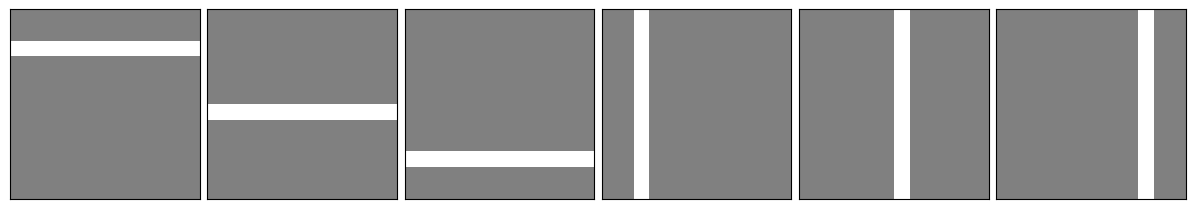

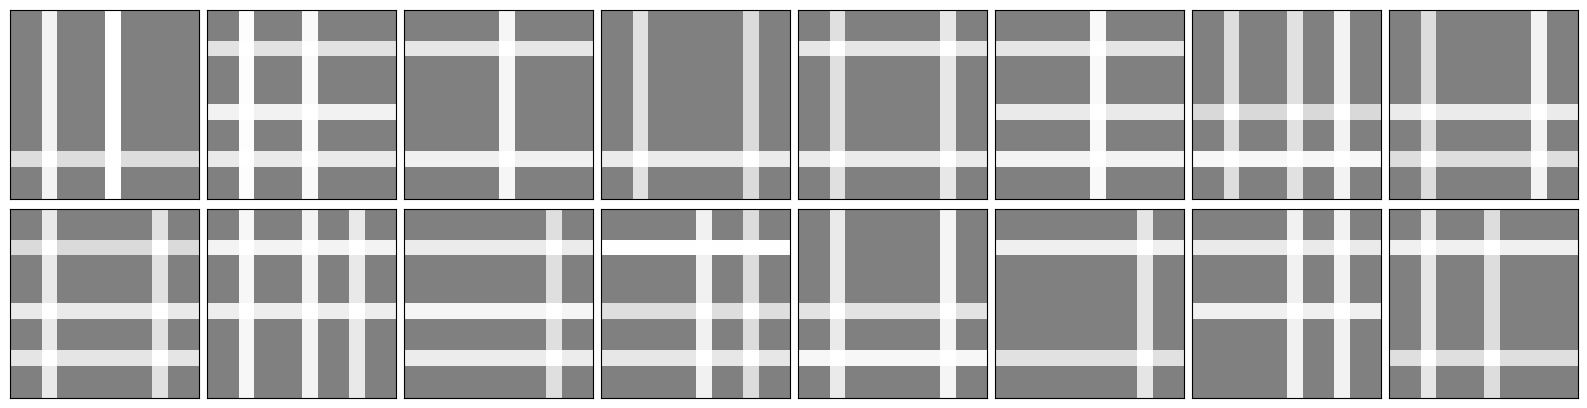

In [3]:
# Ground-truth atoms: thin horizontal/vertical bars on a 12x12 grid.
# Each atom is a single connected component (b_0 = 1, b_1 = 0).
# Sums of multiple atoms produce grid-like samples with non-trivial topology
# (multiple components when parallel bars are picked, enclosed holes when
# horizontal and vertical bars cross).

image_shape_synth = (12, 12)
h_rows = (2, 6, 9)
v_cols = (2, 6, 9)

def make_bar_atoms(image_shape, h_rows, v_cols):
    H, W = image_shape
    atoms = []
    labels = []
    for r in h_rows:
        a = np.zeros((H, W), dtype=np.float32)
        a[r, :] = 1.0
        atoms.append(a); labels.append(f"H@row{r}")
    for c in v_cols:
        a = np.zeros((H, W), dtype=np.float32)
        a[:, c] = 1.0
        atoms.append(a); labels.append(f"V@col{c}")
    return np.stack(atoms, axis=0), labels

def generate_overlap_samples(atoms, num_samples=30, min_k=3, max_k=5,
                             weight_range=(0.7, 1.0), seed=42):
    rng = np.random.default_rng(seed)
    K, H, W = atoms.shape
    samples = np.zeros((num_samples, H, W), dtype=np.float32)
    for i in range(num_samples):
        k = rng.integers(min_k, max_k + 1)
        idx = rng.choice(K, size=int(k), replace=False)
        weights = rng.uniform(*weight_range, size=int(k)).astype(np.float32)
        samples[i] = (atoms[idx] * weights[:, None, None]).sum(axis=0)
    return np.clip(samples, 0.0, 1.0)

ground_truth_atoms, atom_labels = make_bar_atoms(image_shape_synth, h_rows, v_cols)
n_components_synth = ground_truth_atoms.shape[0]
print(f"Ground-truth atoms: {ground_truth_atoms.shape}  (each is a single connected bar)")

# We deliberately use a small number of samples (30) with 3--5 atoms each so
# that overlap is heavy and the problem is not trivially solved by
# least-squares NMF alone.
X_synth = generate_overlap_samples(
    ground_truth_atoms, num_samples=30, min_k=3, max_k=5, seed=42,
)
X_synth_flat = X_synth.reshape(X_synth.shape[0], -1)
print(f"Samples: {X_synth.shape}")

_ = plot_gallery(ground_truth_atoms,
                 #title="Ground-truth atoms",
                 n_row=1, n_col=n_components_synth)
_ = plot_gallery(X_synth[:16],
                 #title="Samples (random overlapping mixtures of atoms)",
                 n_row=2, n_col=8)


### Fit Top-NMF
We use a vertex-based superlevel cubical complex and an empty target persistence
diagram so that each basis vector is pushed toward a single connected blob with
no holes.


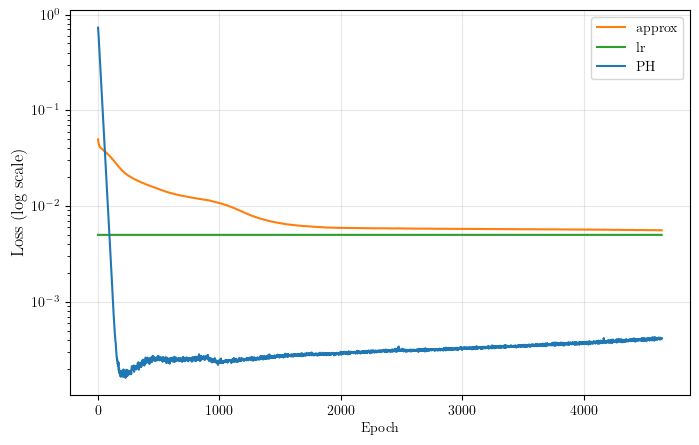

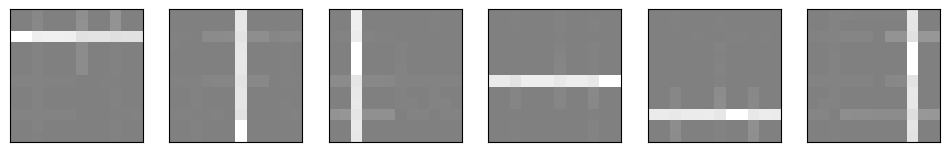

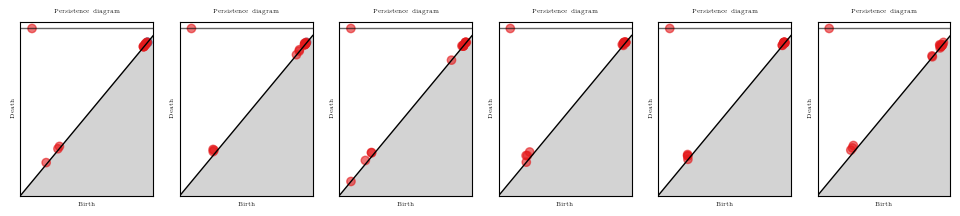

  0%|          | 0/5000 [00:00<?, ?it/s]

Final reconstruction loss: 0.0055


In [5]:
cubical_synth = CubicalComplex(superlevel=True, dim=len(image_shape_synth), mode="V")

target_diagrams_synth = [
    torch.tensor([[]], dtype=torch.float, device=device),
    torch.tensor([[]], dtype=torch.float, device=device),
]

model_synth = TopologicalNMF(
    n_components=n_components_synth,
    device=device,
    complex=cubical_synth,
    ph_loss_fn=target_diagram_loss,
    data_shape=image_shape_synth,
    use_embedding=False,
    random_state=42,
)

monitor_synth = FitMonitor(
    show=["loss", "basis", "PH"],
    interval=50,
    grid=(1, n_components_synth),
    PHmode="V",
    superlevel=True,
    save_video=True,
)

model_synth.fit(
    X_synth_flat,
    n_iterations=5000,
    lr=0.005,
    lambda_top=1.0,
    weight_decay=0.1,
    PH_dims=[0, 1],
    start_epoch_topological=0,
    verbose=True,
    target_diagrams=target_diagrams_synth,
    init_method="nndsvdar",
    monitor=monitor_synth,
)

V_synth = model_synth.V.detach().cpu().numpy()
print(f"Final reconstruction loss: {model_synth.losses['approx'][-1]:.4f}")
plt.close("all")


In [ ]:
monitor_synth.save("synthetic_bars.mp4", show=["basis", "PH"], fps=5)


### Compare with standard NMF
With the same number of components, standard NMF mixes overlapping atoms and
typically returns grid-like or fragmented bases. Top-NMF recovers the
ground-truth single-bar atoms much more cleanly. The atom-recovery score below
is the mean cosine similarity between recovered bases and ground-truth atoms
under the optimal permutation.


Atom-recovery score (mean cosine similarity, higher = better):
  Top-NMF       : 0.989
  Standard NMF  : 0.841
Reconstruction RMSE on training samples (lower = better fit):
  Top-NMF       : 0.0733
  Standard NMF  : 0.0544


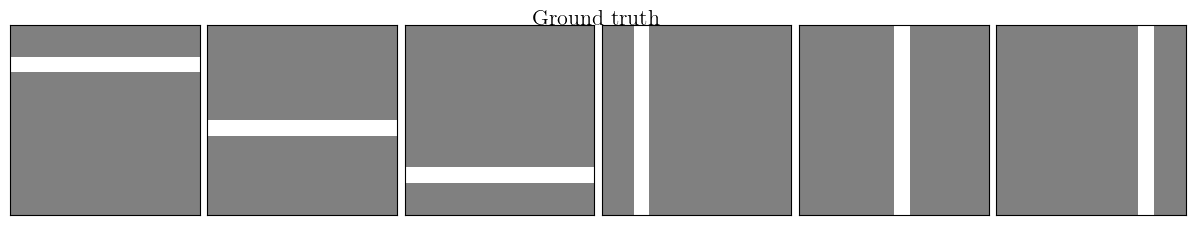

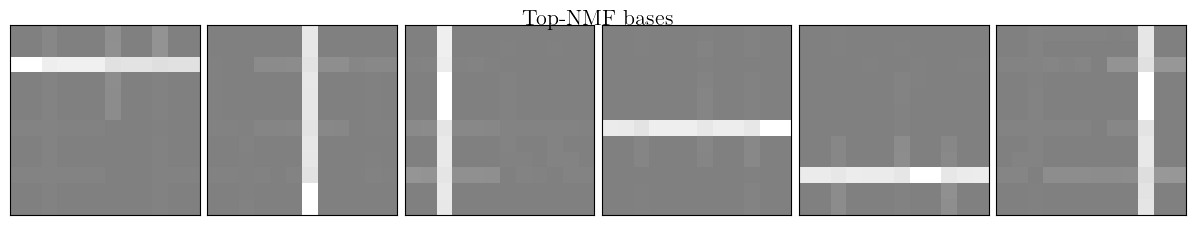

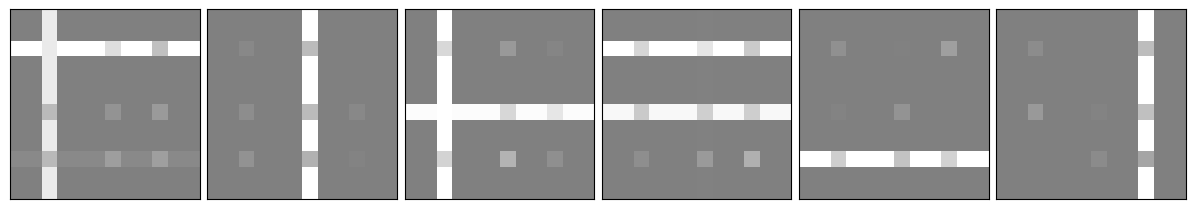

In [ ]:
from sklearn.decomposition import NMF
from scipy.optimize import linear_sum_assignment

nmf_synth = NMF(n_components=n_components_synth, init="nndsvda",
                random_state=0, max_iter=5000)
nmf_synth.fit(X_synth_flat)
V_synth_std = nmf_synth.components_

_ = plot_gallery(ground_truth_atoms,
                 title="Ground truth", n_row=1, n_col=n_components_synth)
_ = plot_gallery(V_synth.reshape(-1, *image_shape_synth),
                 title="Top-NMF bases", n_row=1, n_col=n_components_synth)
_ = plot_gallery(V_synth_std.reshape(-1, *image_shape_synth),
                 title="Standard NMF bases",
                 n_row=1, n_col=n_components_synth)


def _row_normalize(M):
    norms = np.linalg.norm(M, axis=1, keepdims=True)
    return M / np.where(norms > 0, norms, 1.0)


def atom_recovery_score(V_est, atoms_true):
    A_est = _row_normalize(V_est.reshape(V_est.shape[0], -1))
    A_true = _row_normalize(atoms_true.reshape(atoms_true.shape[0], -1))
    cost = -A_est @ A_true.T
    row, col = linear_sum_assignment(cost)
    return float(-cost[row, col].mean())


def reconstruction_rmse(X_flat, basis):
    # Non-negative least squares on the basis to fit each sample.
    from scipy.optimize import nnls
    rmses = []
    B = basis.reshape(basis.shape[0], -1)
    for x in X_flat:
        u, _ = nnls(B.T, x)
        rmses.append(np.sqrt(np.mean((B.T @ u - x) ** 2)))
    return float(np.mean(rmses))


print("Atom-recovery score (mean cosine similarity, higher = better):")
print(f"  Top-NMF       : {atom_recovery_score(V_synth, ground_truth_atoms):.3f}")
print(f"  Standard NMF  : {atom_recovery_score(V_synth_std, ground_truth_atoms):.3f}")

print("Reconstruction RMSE on training samples (lower = better fit):")
print(f"  Top-NMF       : {reconstruction_rmse(X_synth_flat, V_synth):.4f}")
print(f"  Standard NMF  : {reconstruction_rmse(X_synth_flat, V_synth_std):.4f}")


---
## Real-world example: font glyphs

We now apply Top-NMF to two real-world image datasets in which the underlying
"atoms" are not exactly known, but where interpretable structure -- strokes
shared across many glyphs -- is expected. Although there is no ground truth
to score against, the recovered Top-NMF bases align visually with linguistic
sub-structures (radicals/components for kanji, jamo-like strokes for hangul),
while standard NMF produces less interpretable bases.


### Kanji: radical + component decomposition
Each synthesised glyph is built from a radical (left part) and a component
(right part) drawn from a CJK font. Top-NMF should recover bases that align
with these reusable parts.


#### Generate Kanji character images


In [ ]:
# Download a CJK font for extracting real glyph components
font_file = "NotoSansCJKjp-Regular.otf"
try:
    base_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    base_dir = os.getcwd()
font_path = os.path.join(base_dir, font_file)

if not os.path.exists(font_path):
    url = "https://raw.githubusercontent.com/notofonts/noto-cjk/main/Sans/OTF/Japanese/NotoSansCJKjp-Regular.otf"
    urlretrieve(url, font_path)
    print("Font downloaded:", font_path)
else:
    print("Using existing font:", font_path)

In [ ]:
def _crop_to_content(image: np.ndarray) -> np.ndarray:
    """Crop a binary image to its non-zero bounding box."""
    ys, xs = np.nonzero(image)
    if len(xs) == 0:
        raise ValueError("No foreground pixels found while extracting glyph component.")
    y0, y1 = int(ys.min()), int(ys.max()) + 1
    x0, x1 = int(xs.min()), int(xs.max()) + 1
    return image[y0:y1, x0:x1]


def _render_glyph_image(
    char: str,
    font: ImageFont.FreeTypeFont,
    canvas_size: Tuple[int, int],
) -> np.ndarray:
    """Render a centered glyph to a binary image."""
    width, height = canvas_size
    img = Image.new("L", (width, height), color=0)
    draw = ImageDraw.Draw(img)
    bbox = draw.textbbox((0, 0), char, font=font)
    glyph_w, glyph_h = bbox[2] - bbox[0], bbox[3] - bbox[1]
    x = (width - glyph_w) / 2 - bbox[0]
    y = (height - glyph_h) / 2 - bbox[1]
    draw.text((x, y), char, fill=255, font=font)
    arr = np.array(img, dtype=np.uint8)
    return (arr > 127).astype(np.uint8) * 255


def _extract_template_from_glyph(
    glyph: str,
    font: ImageFont.FreeTypeFont,
    target_size: Tuple[int, int],
    canvas_size: Tuple[int, int],
) -> np.ndarray:
    """Render a glyph and resize to target template size."""
    full = _render_glyph_image(glyph, font=font, canvas_size=canvas_size)
    tight = _crop_to_content(full)
    resample_ns = getattr(Image, "Resampling", Image)
    resized = Image.fromarray(tight).resize(target_size, resample=resample_ns.NEAREST)
    return np.array(resized, dtype=np.uint8)

def _pad_templates_for_gallery(templates: Dict[str, np.ndarray], keys: List[str]) -> np.ndarray:
    """Pad variable-size templates so they can be visualized in a single gallery."""
    max_h = max(templates[k].shape[0] for k in keys)
    max_w = max(templates[k].shape[1] for k in keys)
    padded: List[np.ndarray] = []
    for k in keys:
        t = templates[k]
        canvas = np.zeros((max_h, max_w), dtype=np.uint8)
        y0 = (max_h - t.shape[0]) // 2
        x0 = (max_w - t.shape[1]) // 2
        canvas[y0 : y0 + t.shape[0], x0 : x0 + t.shape[1]] = t
        padded.append(canvas)
    return np.stack(padded, axis=0)


def _paste_exact(canvas: np.ndarray, part: np.ndarray, top: int, left: int) -> None:
    """Paste `part` at an exact location; raise if any clipping would occur."""
    part_h, part_w = part.shape
    if top < 0 or left < 0 or top + part_h > canvas.shape[0] or left + part_w > canvas.shape[1]:
        raise ValueError(
            f"Part does not fit at fixed anchor (top={top}, left={left}, shape={part.shape}) "
            f"within canvas shape={canvas.shape}."
        )
    canvas[top : top + part_h, left : left + part_w] = np.maximum(
        canvas[top : top + part_h, left : left + part_w], part
    )


def generate_kanji_overlapping_parts_images(
    image_size: Tuple[int, int] = (64, 64),
    radical_height: int = 46,
    radical_widths: Dict[str, int] | None = None,
    component_size: Tuple[int, int] = (28, 46),
    component_sizes: Dict[str, Tuple[int, int]] | None = None,
    selected_combinations: Dict[str, Tuple[str, str]] | None = None,
    donor_canvas_size: Tuple[int, int] = (96, 96),
    donor_font_size: int = 82,
    radical_anchor: Tuple[int, int] = (9, 4),
    radical_x_offsets: Dict[str, int] | None = None,
    radical_y_offsets: Dict[str, int] | None = None,
    component_anchor: Tuple[int, int] = (9, 32),
    component_y_offsets: Dict[str, int] | None = None,
) -> Tuple[np.ndarray, List[str], Dict[str, object], np.ndarray, np.ndarray]:
    """Synthesize kanji images from connected font-derived templates.

    Parameters
    ----------
    selected_combinations : dict[str, tuple[str, str]] or None
        Mapping of output label -> (radical, component).
        If None, all 3x3 combinations are generated.
    """
    height, width = image_size
    radicals = list(radical_x_offsets.keys())
    components = list(component_y_offsets.keys())

    for label, (radical, component) in selected_combinations.items():
        if radical not in radicals:
            raise ValueError(f"Unknown radical in selected_combinations[{label!r}]: {radical}")
        if component not in components:
            raise ValueError(f"Unknown component in selected_combinations[{label!r}]: {component}")

    font_file = "NotoSansCJKjp-Regular.otf"
    font_candidates = [
        os.path.join(os.getcwd(), font_file),
        os.path.join(os.getcwd(), "notebook", font_file),
    ]
    try:
        font_candidates.insert(0, os.path.join(os.path.dirname(os.path.abspath(__file__)), font_file))
    except NameError:
        pass

    font_path = next((p for p in font_candidates if os.path.exists(p)), None)
    font = ImageFont.truetype(font_path, donor_font_size)

    radical_templates = {
        r: _extract_template_from_glyph(
            glyph=r,
            font=font,
            target_size=(int(radical_widths[r]), int(radical_height)),
            canvas_size=donor_canvas_size,
        )
        for r in radicals
    }
    component_templates = {
        c: _extract_template_from_glyph(
            glyph=c,
            font=font,
            target_size=component_sizes[c],
            canvas_size=donor_canvas_size,
        )
        for c in components
    }

    radical_stack = _pad_templates_for_gallery(radical_templates, radicals)
    component_stack = _pad_templates_for_gallery(component_templates, components)

    rad_top, rad_left = radical_anchor
    comp_top, comp_left = component_anchor

    images: List[np.ndarray] = []
    labels: List[str] = []
    for label, (radical, component) in selected_combinations.items():
        canvas = np.zeros((height, width), dtype=np.uint8)
        _paste_exact(
            canvas,
            radical_templates[radical],
            top=rad_top + radical_y_offsets[radical],
            left=rad_left + radical_x_offsets[radical],
        )
        _paste_exact(
            canvas,
            component_templates[component],
            top=comp_top + component_y_offsets[component],
            left=comp_left,
        )
        images.append(canvas)
        labels.append(label)

    group_info = {
        "radicals": radicals,
        "components": components,
        "radical_widths": radical_widths,
        "anchors": {"radical": radical_anchor, "component": component_anchor},
        "radical_x_offsets": radical_x_offsets,
        "radical_y_offsets": radical_y_offsets,
        "component_sizes": component_sizes,
        "component_y_offsets": component_y_offsets,
        "selected_combinations": selected_combinations,
    }
    return np.stack(images, axis=0), labels, group_info, radical_stack, component_stack


images_kanji, labels_kanji, groups_kanji, radical_templates, component_templates = (
    generate_kanji_overlapping_parts_images(
        radical_widths={"木": 22, "亻": 14, "虫": 22},
        radical_x_offsets={"木": 3, "亻": 7, "虫": 3},
        radical_y_offsets={"木": 0, "亻": 0, "虫": 0},
        component_sizes={"工": (28, 40), "古": (28, 46), "由": (28, 46)},
        component_y_offsets={"工": 6, "古": 0, "由": 0},
        selected_combinations = {
            "枯": ("木", "古"),
            "柚": ("木", "由"),
            "杠": ("木", "工"),
            "伷": ("亻", "由"),
            "仜": ("亻", "工"),
            "估": ("亻", "古"),
            "虹": ("虫", "工"),
            "蛄": ("虫", "古"),
            "蚰": ("虫", "由"),
        },
        radical_anchor=(9, 4),
        component_anchor=(9, 32),
    )
)
print(f"Generated {len(labels_kanji)} images, shape: {images_kanji.shape}")

# Keep exact binary patterns for linear basis extraction
X_kanji = (images_kanji > 127).astype(np.float32)

n_components_kanji = len(groups_kanji["radicals"]) + len(groups_kanji["components"])
data_dims_kanji = X_kanji.shape[1:]

X_kanji_flat = X_kanji.reshape(X_kanji.shape[0], -1)

print(f"Data: {X_kanji.shape}")
n_col = min(3, X_kanji.shape[0])
n_row = int(np.ceil(X_kanji.shape[0] / n_col))
_ = plot_gallery(X_kanji, n_row=n_row, n_col=n_col)


#### Fit Top-NMF


In [ ]:
target_diagrams_kanji = [
    torch.tensor([[]], dtype=torch.float, device=device),
    torch.tensor([[]], dtype=torch.float, device=device),
]

cubical_kanji = CubicalComplex(superlevel=True, dim=len(data_dims_kanji), mode="V")

model_kanji = TopologicalNMF(
    n_components=n_components_kanji,
    device=device,
    random_state=42,
    complex=cubical_kanji,
    ph_loss_fn=target_diagram_loss,
    data_shape=data_dims_kanji,
    use_embedding=False,
)

monitor_kanji = FitMonitor(
    show=["loss", "basis", "PH"],
    interval=100,
    factor=1.0,
    grid=(2, 3),
    PHmode="V",
    superlevel=True,
    save_video=True
)

model_kanji.fit(
    X_kanji_flat,
    n_iterations=5000,
    lr=0.005,
    PH_dims=[0],
    lambda_top=0.4,
    weight_decay=0.1,
    verbose=True,
    target_diagrams=target_diagrams_kanji,
    init_method="nndsvda",
    monitor=monitor_kanji,
)

V_kanji = model_kanji.V.detach().cpu().numpy()
print(f"Final reconstruction loss: {model_kanji.losses['approx'][-1]:.4f}")
plt.close("all")

In [ ]:
monitor_kanji.save("image2d.mp4", show=["basis","PH"], fps=5)


#### Compare with standard NMF


In [ ]:
from sklearn.decomposition import NMF

plot_gallery(
    V_kanji.reshape(-1, *data_dims_kanji),
    title="Top-NMF bases",
    n_row=2,
    n_col=3,
)

nmf_kanji = NMF(n_components=n_components_kanji, init="nndsvda", random_state=0)
nmf_kanji.fit_transform(X_kanji_flat)
H_kanji_std = nmf_kanji.components_

plot_gallery(
    H_kanji_std.reshape(-1, *data_dims_kanji),
    title="Standard NMF bases",
    n_row=2,
    n_col=3,
)

### Hangul: stroke decomposition
Hangul characters decompose into reusable jamo-like strokes. We add a small
amount of intensity variation to demonstrate robustness.


#### Generate Hangul character images


In [ ]:
# Download the Nanum Gothic font for rendering Hangul characters
if not os.path.exists("NanumGothicCoding-Regular.ttf"):
    url = "https://github.com/google/fonts/raw/main/ofl/nanumgothiccoding/NanumGothicCoding-Regular.ttf"
    urlretrieve(url, "NanumGothicCoding-Regular.ttf")
    print("Font downloaded.")

In [ ]:
def generate_hangul_images(image_size=(64, 64), font_size=48):
    """Render six Hangul characters as grayscale images."""
    try:
        base_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        base_dir = os.getcwd()

    labels = ['가','다','라','갸','댜','랴']
    font_path = os.path.join(base_dir, "NanumGothicCoding-Regular.ttf")
    font = ImageFont.truetype(font_path, font_size)
    W, H = image_size
    images = []

    for ch in labels:
        img = Image.new('L', (W, H), color=0)
        draw = ImageDraw.Draw(img)
        bbox = draw.textbbox((0, 0), ch, font=font)
        w, h = bbox[2] - bbox[0], bbox[3] - bbox[1]
        draw.text(((W - w) / 2, (H - h) / 2), ch, fill=255, font=font)
        images.append(np.array(img, dtype=np.uint8))

    return np.stack(images, axis=0), labels

images_array, labels = generate_hangul_images(font_size=48)
print(f"Generated {len(labels)} images, shape: {images_array.shape}")

In [ ]:
# Binarize and add random intensity variation
X_hangul = (images_array > 127).astype(np.float32)
X_hangul *= np.random.uniform(low=0.5, high=1.0, size=X_hangul.shape)

n_components_hangul = 5
data_dims_hangul = X_hangul.shape[1:]  # (64, 64)

print(f"Data: {X_hangul.shape}")
plot_gallery(X_hangul, n_row=1, n_col=6)

#### Fit Top-NMF


In [ ]:
# Empty target diagrams encourage topologically simple bases
target_diagrams_hangul = [
    torch.tensor([[]], dtype=torch.float, device=device),
    torch.tensor([[]], dtype=torch.float, device=device),
]

# Vertex-based superlevel cubical complex for 2-D images
cubical_hangul = CubicalComplex(superlevel=True, dim=len(data_dims_hangul), mode="V")

model_hangul = TopologicalNMF(
    n_components=n_components_hangul,
    device=device,
    random_state=42,
    complex=cubical_hangul,
    ph_loss_fn=target_diagram_loss,
    data_shape=data_dims_hangul,
    use_embedding=False,
)

monitor_hangul = FitMonitor(
    show=["loss", "basis", "PH"],
    interval=10,
    grid=(1, 5),
    PHmode="V",
    superlevel=True,
)

# Flatten spatial dims for NMF: (n_samples, n_features)
X_hangul_flat = X_hangul.reshape(X_hangul.shape[0], -1)

model_hangul.fit(
    X_hangul_flat,
    n_iterations=30000,
    lr=0.001,
    PH_dims=[0],
    lambda_top=0.7,
    weight_decay=0.2,
    verbose=True,
    target_diagrams=target_diagrams_hangul,
    init_method="nndsvda",
    monitor=monitor_hangul,
)

V_hangul = model_hangul.V.detach().cpu().numpy()
print(f"Final reconstruction loss: {model_hangul.losses['approx'][-1]:.4f}")

#### Compare with standard NMF


In [ ]:
from sklearn.decomposition import NMF

# Top-NMF basis vectors
plot_gallery(V_hangul.reshape(-1, *data_dims_hangul), title="Top-NMF bases", n_row=1, n_col=5)

# Standard NMF for comparison
nmf = NMF(n_components=n_components_hangul, init="nndsvda", random_state=0)
nmf.fit_transform(X_hangul_flat)
H_std = nmf.components_

plot_gallery(H_std.reshape(-1, *data_dims_hangul), title="Standard NMF bases", n_row=1, n_col=5)